# Notebook for the evaluation of Trained Default Prediction Models 

For assembly models, all available features will be used, including text strings, and no preprocessing, null data management, or categorical variable encoding will be performed.

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = Path().resolve().parent.parent / "data/data-09-2025"
data_file = "data_default_clean.parquet"

merged_df = pd.read_parquet(DATA_DIR / data_file)

X = merged_df.drop("default", axis=1)

# The type of categorical variables is changed to ‘category’ so that the models
# can handle them correctly.
categorical_features = X.select_dtypes(include="object").columns.to_list()
X[categorical_features] = X[categorical_features].astype("category")

y = merged_df["default"]

# We separate the data into training and testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

# Pipelines with Skrub

### Light GBM model with tabular pipeline skrub without hyperparameter tuning

In [2]:
from lightgbm import LGBMClassifier
from skrub import tabular_pipeline

lgb_model_best = LGBMClassifier(
    objective="binary",  # Objetivo de clasificación binaria
    class_weight="balanced",  # Hace balanceo de clases
    colsample_bytree=0.9005463006833063,
    learning_rate=0.12023779811254239,
    max_depth=10,
    min_child_samples=39,
    n_estimators=105,
    num_leaves=64,
    reg_alpha=0.096,
    reg_lambda=0.003019661310620262,
    scale_pos_weight=2.007887722293911,
    subsample=0.7707980192130739,
    verbose=0,
)

# 1. Crear el learner
model_skrub = tabular_pipeline(lgb_model_best)

# 2. Entrenar el modelo
model_skrub.fit(X_train, y_train)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,steps,"[('tablevectorizer', ...), ('squashingscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cardinality_threshold,40
,low_cardinality,OneHotEncoder..._output=False)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncod...ding='spline')
,specific_transformers,()
,drop_null_fraction,1.0


In [3]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test, model_skrub.predict(X_test), target_names=["No default", "Default"]
    )
)

              precision    recall  f1-score   support

  No default       0.96      0.94      0.95      2127
     Default       0.75      0.81      0.78       446

    accuracy                           0.92      2573
   macro avg       0.86      0.88      0.87      2573
weighted avg       0.92      0.92      0.92      2573



c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


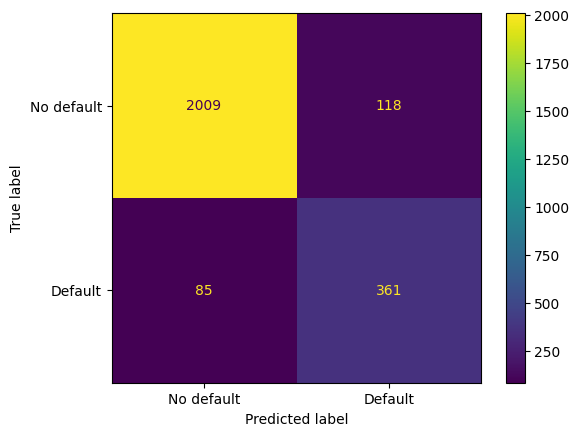

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model_skrub, X_test, y_test, display_labels=["No default", "Default"]
)

### Pipeline with Skrub table vectorizer, LGBM model, and hyperparameter tuning

In [5]:
import warnings

from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from skrub import TableVectorizer

warnings.filterwarnings("ignore")

pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        ("clf", LGBMClassifier(objective="binary", random_state=42)),
    ]
)

param_distributions = {
    "clf__num_leaves": randint(20, 150),
    "clf__max_depth": randint(3, 15),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__n_estimators": randint(50, 500),
    "clf__min_child_samples": randint(2, 50),
    "clf__subsample": uniform(0.5, 0.5),  # de 0.5 a 1.0
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__eg_alpha": loguniform(1e-3, 10),
    "clf__reg_lambda": loguniform(1e-3, 10),
    "clf__scale_pos_weight": uniform(1, 10),  # Hiperparámetro para balancear clases
}

grid_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1_weighted",
)
grid_search.fit(X_train, y_train)

test_score = f1_score(y_test, grid_search.predict(X_test), average="weighted")
print(f"Best score: {grid_search.best_score_:.3f} with {grid_search.best_params_}")
print(f"Test score: {test_score:.3f}")

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [6]:
print(classification_report(y_test, grid_search.predict(X_test)))

[LightGBM] [Warning] Unknown parameter: eg_alpha
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2127
           1       0.85      0.75      0.80       446

    accuracy                           0.93      2573
   macro avg       0.90      0.86      0.88      2573
weighted avg       0.93      0.93      0.93      2573



[LightGBM] [Warning] Unknown parameter: eg_alpha


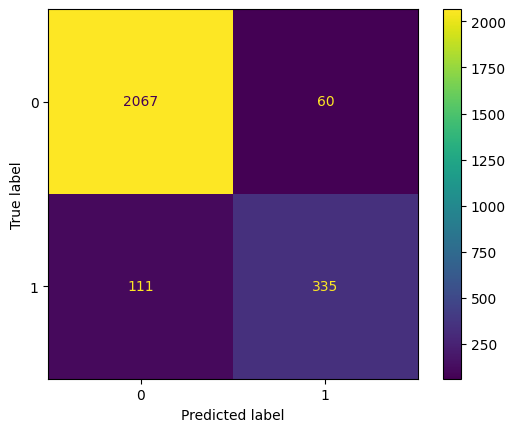

In [7]:
ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test)

This is the model with the best performance

In [ ]:
import joblib

MODELS_DIR = Path().resolve().parent / "models"

best_skrub = grid_search.best_estimator_
joblib.dump(best_skrub, MODELS_DIR / "lgb_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\lgb_model.joblib']

In [ ]:
# Guardar hiperparámetros del modelo en en un archivo JSON
import json

with open(MODELS_DIR / "lgb_model_params.json", "w") as f:
    json.dump(grid_search.best_params_, f, indent=4)

### Skrub con modelo por defecto y ajuste de hiperparametros

In [ ]:
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = tabular_pipeline("classifier")

param_grid = {
    "histgradientboostingclassifier__learning_rate": [0.1, 0.05, 0.02],
    "histgradientboostingclassifier__max_iter": [200, 400, 800],
    "histgradientboostingclassifier__max_leaf_nodes": [31, 63, 127],
    "histgradientboostingclassifier__min_samples_leaf": [10, 20, 40],
    "histgradientboostingclassifier__l2_regularization": [0.0, 0.1, 1.0],
    "histgradientboostingclassifier__early_stopping": [True],
}

# 3) Métrica y CV (para 5 clases sueles preferir f1_macro)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average="macro")

# 4) Grid search
search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)
best_pipe = search.best_estimator_

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor f1_macro (CV):", search.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores hiperparámetros: {'histgradientboostingclassifier__early_stopping': True, 'histgradientboostingclassifier__l2_regularization': 0.1, 'histgradientboostingclassifier__learning_rate': 0.05, 'histgradientboostingclassifier__max_iter': 200, 'histgradientboostingclassifier__max_leaf_nodes': 31, 'histgradientboostingclassifier__min_samples_leaf': 20}
Mejor f1_macro (CV): 0.870444617700642


In [ ]:
y_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2127
           1       0.84      0.69      0.76       446

    accuracy                           0.92      2573
   macro avg       0.89      0.83      0.86      2573
weighted avg       0.92      0.92      0.92      2573



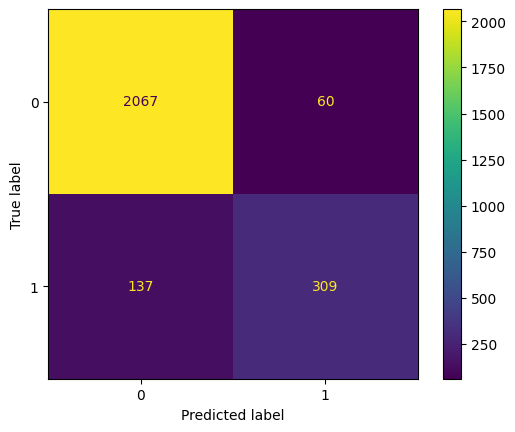

In [40]:
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test)

In [44]:
best_skrub = search.best_estimator_
joblib.dump(best_skrub, MODELS_DIR / "hist_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\hist_model.joblib']

In [43]:
with open(MODELS_DIR / "hist_model_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=4)

# Skrub with other models

## Skrub + xgbost

In [ ]:
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
model_xgb = XGBClassifier(
    grow_policy="lossguide",
    tree_method="hist",
    enable_categorical=True,  # Allows categorical variables to be handled directly
)

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        ("clf", model_xgb),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "clf__max_depth": randint(3, 15),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__n_estimators": randint(1, 500),
    "clf__subsample": uniform(0.5, 0.5),  # de 0.5 a 1.0
    "clf__colsample_bytree": uniform(0.5, 0.5),
    "clf__reg_alpha": loguniform(1e-3, 10),
    "clf__reg_lambda": loguniform(1e-3, 10),
    "clf__max_delta_step": randint(0, 10),
    "clf__gamma": uniform(0, 2),
    "clf__min_child_weight": randint(5, 10),
    "clf__scale_pos_weight": uniform(
        1, 10
    ),  # Con este hiperparámetro se balancean las clases
}

grid_search_xgb = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_xgb.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_xgb.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_xgb.best_score_:.3f} with {grid_search_xgb.best_params_}"
)
print(f"Test score: {test_score:.3f}")

Best score: 0.929 with {'clf__colsample_bytree': np.float64(0.5041048801549949), 'clf__gamma': np.float64(0.848180954683738), 'clf__learning_rate': np.float64(0.019497829212420246), 'clf__max_delta_step': 6, 'clf__max_depth': 7, 'clf__min_child_weight': 7, 'clf__n_estimators': 438, 'clf__reg_alpha': np.float64(0.4891966206485603), 'clf__reg_lambda': np.float64(0.036274299407536716), 'clf__scale_pos_weight': np.float64(2.3002916390278605), 'clf__subsample': np.float64(0.9799191391343041)}
Test score: 0.925


In [46]:
best_pipe_xgb = grid_search_xgb.best_estimator_

y_pred = best_pipe_xgb.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2127
           1       0.79      0.77      0.78       446

    accuracy                           0.93      2573
   macro avg       0.87      0.86      0.87      2573
weighted avg       0.92      0.93      0.93      2573



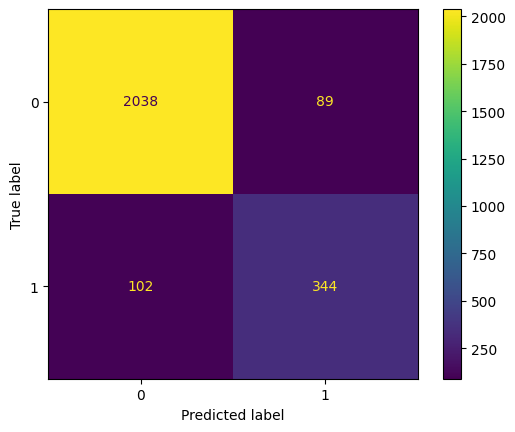

In [47]:
ConfusionMatrixDisplay.from_estimator(best_pipe_xgb, X_test, y_test)

In [48]:
joblib.dump(best_pipe_xgb, MODELS_DIR / "xgb_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\xgb_model.joblib']

In [50]:
with open(MODELS_DIR / "xgb_model_params.json", "w") as f:
    json.dump(grid_search_xgb.best_params_, f, indent=4)

## Skrub + random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
rfc_model = RandomForestClassifier(
    class_weight="balanced"  # Hace balanceo de clases
)

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        ("classifier", rfc_model),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__n_estimators": randint(50, 500),
    "classifier__max_depth": randint(3, 15),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__min_samples_leaf": randint(1, 20),
    "classifier__max_features": ["auto", "sqrt", "log2", None],
    "classifier__bootstrap": [True, False],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
}

grid_search_rfc = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_rfc.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_rfc.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_rfc.best_score_:.3f} with {grid_search_rfc.best_params_}"
)
print(f"Test score: {test_score:.3f}")

Best score: 0.911 with {'classifier__bootstrap': True, 'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 17, 'classifier__n_estimators': 107}
Test score: 0.910


In [52]:
best_pipe_rfc = grid_search_rfc.best_estimator_

y_pred = best_pipe_rfc.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.953     0.935     0.944      2127
           1      0.715     0.783     0.747       446

    accuracy                          0.908      2573
   macro avg      0.834     0.859     0.846      2573
weighted avg      0.912     0.908     0.910      2573



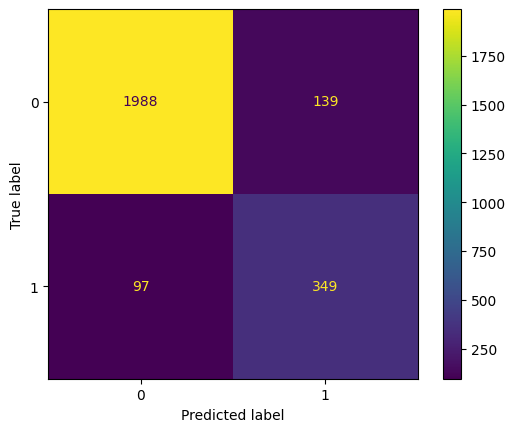

In [53]:
ConfusionMatrixDisplay.from_estimator(best_pipe_rfc, X_test, y_test)

In [54]:
joblib.dump(best_pipe_rfc, MODELS_DIR / "rfc_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\rfc_model.joblib']

In [55]:
with open(MODELS_DIR / "rfc_model_params.json", "w") as f:
    json.dump(grid_search_rfc.best_params_, f, indent=4)

## Skrub + logistic regresion

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),  # StandardScaler para datos dispersos
        (
            "classifier",
            LogisticRegression(
                solver="liblinear", max_iter=1000, class_weight="balanced"
            ),
        ),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": loguniform(1e-3, 1e3),
}

grid_search_lrc = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_lrc.fit(X_train, y_train)

test_score = f1_score(y_test, grid_search_lrc.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_lrc.best_score_:.3f} with {grid_search_lrc.best_params_}"
)
print(f"Test score: {test_score:.3f}")

KeyboardInterrupt: 

In [40]:
best_pipe_lrc = grid_search_lrc.best_estimator_
y_pred = best_pipe_lrc.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.957     0.816     0.881      2148
           1      0.467     0.816     0.594       425

    accuracy                          0.816      2573
   macro avg      0.712     0.816     0.738      2573
weighted avg      0.876     0.816     0.833      2573



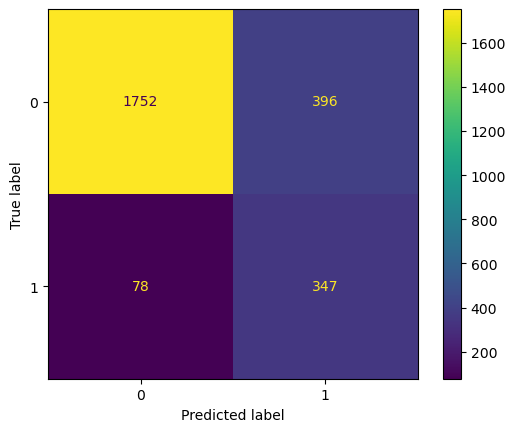

In [41]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lrc, X_test, y_test)

In [42]:
joblib.dump(best_pipe_lrc, "best_pipe_lrc.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

['best_pipe_lrc.joblib']

## Skrub + logistic regresor classifier + balance de clases

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = ImbPipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),  # StandardScaler para datos dispersos
        (
            "undersampling",
            RandomUnderSampler(sampling_strategy="majority", random_state=1),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear", max_iter=1000, class_weight="balanced"
            ),
        ),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": loguniform(1e-3, 1e3),
}

grid_search_lrc_bal = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_lrc_bal.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_lrc_bal.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_lrc_bal.best_score_:.3f} with {grid_search_lrc_bal.best_params_}"
)
print(f"Test score: {test_score:.3f}")

Best score: 0.835 with {'classifier__C': np.float64(12.496206021055345), 'classifier__penalty': 'l1'}
Test score: 0.827


In [44]:
best_pipe_lrc_bal = grid_search_lrc_bal.best_estimator_
y_pred = best_pipe_lrc_bal.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.959     0.804     0.875      2148
           1      0.455     0.828     0.587       425

    accuracy                          0.808      2573
   macro avg      0.707     0.816     0.731      2573
weighted avg      0.876     0.808     0.827      2573



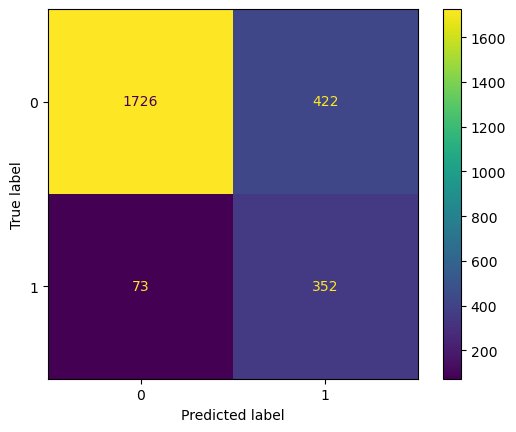

In [45]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lrc_bal, X_test, y_test)

In [46]:
joblib.dump(best_pipe_lrc_bal, "best_pipe_lrc_bal.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

['best_pipe_lrc_bal.joblib']

## Skrub + Multilayer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline(
    [
        ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
        (
            "scaler",
            StandardScaler(with_mean=False),
        ),  # StandardScaler para datos dispersos
        (
            "classifier",
            MLPClassifier(
                learning_rate_init=0.001, hidden_layer_sizes=[10], activation="logistic"
            ),
        ),
    ]
)

# This is the list of hyperparameters to tune
param_distributions = {
    "classifier__max_iter": [1000],
    "classifier__alpha": 10.0 ** -np.arange(-3, 2),
    "classifier__learning_rate_init": loguniform(0.001, 0.1),
    "classifier__hidden_layer_sizes": [
        (10, 5),
        (20, 10),
        (20,),
        (50, 20),
        (100, 20),
        (100,),
    ],
    "classifier__activation": ["logistic", "tanh", "relu"],
}

grid_search_mlp = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_weighted",
)
grid_search_mlp.fit(
    X_train,
    y_train,
)

test_score = f1_score(y_test, grid_search_mlp.predict(X_test), average="weighted")
print(
    f"Best score: {grid_search_mlp.best_score_:.3f} with {grid_search_mlp.best_params_}"
)
print(f"Test score: {test_score:.3f}")

Best score: 0.888 with {'classifier__activation': 'relu', 'classifier__alpha': np.float64(0.1), 'classifier__hidden_layer_sizes': (20,), 'classifier__learning_rate_init': np.float64(0.001759902574649333), 'classifier__max_iter': 1000}
Test score: 0.879


In [48]:
best_pipe_mlp = grid_search_mlp.best_estimator_
y_pred = best_pipe_mlp.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.907     0.965     0.935      2148
           1      0.739     0.499     0.596       425

    accuracy                          0.888      2573
   macro avg      0.823     0.732     0.765      2573
weighted avg      0.879     0.888     0.879      2573



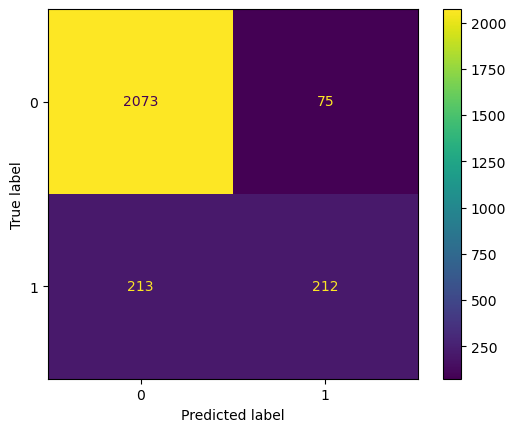

In [49]:
ConfusionMatrixDisplay.from_estimator(best_pipe_mlp, X_test, y_test)

In [50]:
joblib.dump(best_pipe_mlp, "best_pipe_mlp.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

['best_pipe_mlp.joblib']